# Machine Learning Foundations
**Data Preparation
**Assigment 1****

Raya Metchkarova

In [2]:
# all of the necessary libraries for data preparation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 ## Identifying the Prediction Target


In [3]:
df = pd.read_csv('bank-additional.csv', sep=';')
print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns)

Shape of the dataset: (4119, 21)
Columns in the dataset: Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


THe target variable in this dataset is 'y', which indicates whether the client subscribed to a term deposit (yes or no). This variable is what we want to predict based on the other features in the dataset. The 'y' variable is binary, with possible values 'yes' and 'no', making it a classification problem. The goal is to build a model that can predict whether a client will subscribe to a term deposit based on the various features provided in the dataset, such as age, job, marital status, education, and previous campaign outcomes.

In [4]:
TARGET = 'y'
print("Target variable:", TARGET)
print(df[TARGET].value_counts())

Target variable: y
y
no     3668
yes     451
Name: count, dtype: int64


---
### Data Loading and Initial Exploration

In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [10]:
# Looking for difirancig numeric vs categorical variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


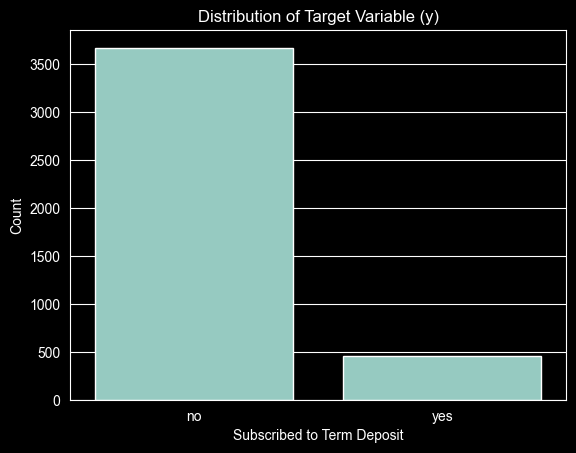

In [16]:
# distribution of the target variable
sns.countplot(x=TARGET, data=df)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

In [15]:
print(f'Ratio of classes in target variable:{df[TARGET].value_counts(normalize=True)}')

Ratio of classes in target variable:y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The target is highly imbalanced, with a majority of 'no' responses. (~89% 'no' and ~10.9% 'yes'). This imbalance will need to be addressed during model training, as it can lead to biased predictions towards the majority class.

In [17]:
# Checking for missing values
# explicitly checking for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [29]:
# Checking for missing values stated as 'unknown'
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of unknown values in categorical columns: {unknown_values}, ({(unknown_values/len(df)*100).round(2)}%)\n")

Count of unknown values in categorical columns: job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64, (job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [30]:
# Special sentinel in pdays: 999 means "not previously contacted"
print(f'\npdays == 999: {(df["pdays"]==999).sum()} ({(df["pdays"]==999).mean()*100:.1f}%)')


pdays == 999: 3959 (96.1%)


---
### Data Slitting

Data splitting is a crucial step in the machine learning pipeline, as it allows us to evaluate the performance of our model on unseen data. We will split the dataset into a training set and a test set. The training set will be used to train the model, while the test set will be used to evaluate its performance.
We will use 70% train, 15% validation, and 15% test split. With ~4,100 rows gives us ~600 significant number for reliable evaluation of the model's performance on the test set.